In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use("ggplot")

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
path = "/Users/ishagoel/Downloads/rainfall.csv"

In [3]:
df = pd.read_csv(path)
df.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,1901,34.7,38.6,17.8,38.9,50.6,113.2,241.4,271.6,124.7,52.4,38.7,8.2,1030.8,73.2,107.3,751.0,99.3
1,1902,7.4,4.2,19.0,44.1,48.8,111.7,284.9,201.0,200.2,62.5,29.4,25.2,1038.4,11.6,111.9,797.8,117.2
2,1903,16.7,8.0,31.1,17.1,59.5,120.3,293.2,274.0,198.1,119.5,40.3,18.0,1195.9,24.7,107.7,885.6,177.8
3,1904,14.9,9.7,31.4,33.7,73.8,165.5,260.3,207.7,130.8,69.8,11.2,16.4,1025.1,24.5,138.8,764.3,97.4
4,1905,24.7,20.3,41.8,33.8,55.8,93.7,253.0,201.7,178.1,54.9,9.6,10.1,977.5,45.0,131.4,726.4,74.7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   YEAR     113 non-null    int64  
 1   JAN      113 non-null    float64
 2   FEB      113 non-null    float64
 3   MAR      113 non-null    float64
 4   APR      113 non-null    float64
 5   MAY      113 non-null    float64
 6   JUN      113 non-null    float64
 7   JUL      113 non-null    float64
 8   AUG      113 non-null    float64
 9   SEP      113 non-null    float64
 10  OCT      113 non-null    float64
 11  NOV      113 non-null    float64
 12  DEC      113 non-null    float64
 13  ANN      113 non-null    float64
 14  Jan-Feb  113 non-null    float64
 15  Mar-May  113 non-null    float64
 16  Jun-Sep  113 non-null    float64
 17  Oct-Dec  113 non-null    float64
dtypes: float64(17), int64(1)
memory usage: 16.0 KB


In [5]:
months = [
    "JAN","FEB","MAR","APR","MAY","JUN",
    "JUL","AUG","SEP","OCT","NOV","DEC"
]

In [6]:
monthly = df.melt(
    id_vars="YEAR",
    value_vars=months,
    var_name="Month",
    value_name="Rainfall"
)

monthly.head()

,YEAR,Month,Rainfall
0,1901,JAN,34.7
1,1902,JAN,7.4
2,1903,JAN,16.7
3,1904,JAN,14.9
4,1905,JAN,24.7


In [7]:
month_map = {
    "JAN":1,
    "FEB":2,
    "MAR":3,
    "APR":4,
    "MAY":5,
    "JUN":6,
    "JUL":7,
    "AUG":8,
    "SEP":9,
    "OCT":10,
    "NOV":11,
    "DEC":12
}

monthly["Month"] = monthly["Month"].map(month_map)

monthly.head()

,YEAR,Month,Rainfall
0,1901,1,34.7
1,1902,1,7.4
2,1903,1,16.7
3,1904,1,14.9
4,1905,1,24.7


In [8]:
monthly["Date"] = pd.to_datetime({
    "year": monthly["YEAR"].astype(int),
    "month": monthly["Month"],
    "day":1
})

In [9]:
monthly = monthly.sort_values("Date")
monthly = monthly.set_index("Date")

monthly = monthly[["Rainfall"]]

monthly.head()

,Rainfall
Date,
1901-01-01,34.7
1901-02-01,38.6
1901-03-01,17.8
1901-04-01,38.9
1901-05-01,50.6


In [10]:
monthly = monthly.asfreq("MS")

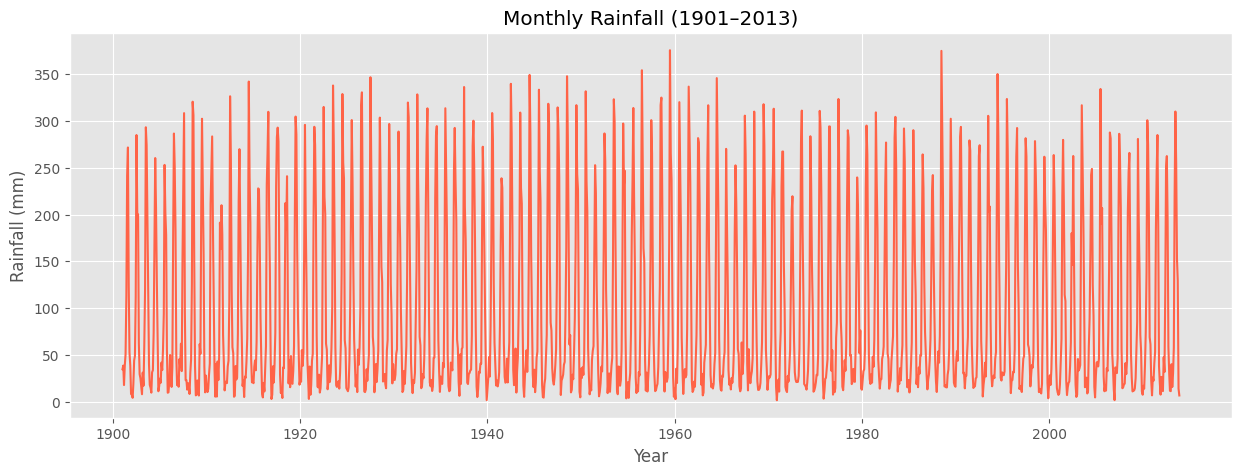

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(monthly["Rainfall"], color="tomato")
plt.title("Monthly Rainfall (1901–2013)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.show()

## Time Series Decomposition

The monthly rainfall series is decomposed into:

- Trend
- Seasonal
- Residual

This helps us understand whether the data contains annual seasonality and long-term trends.

Since rainfall repeats every 12 months, the seasonal period is set to 12.

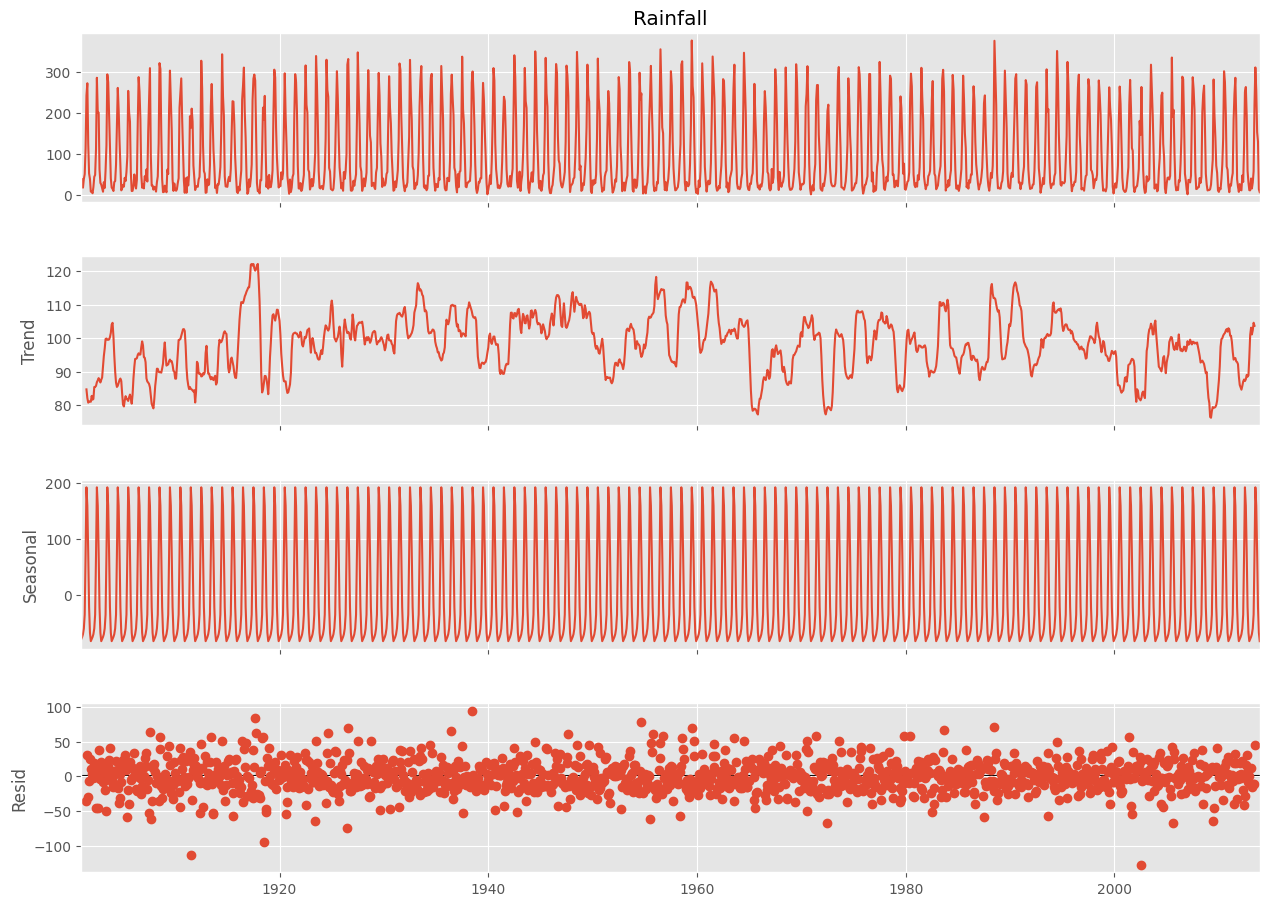

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly["Rainfall"],
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(14,10)

plt.show()

## Stationarity Test

The Augmented Dickey-Fuller (ADF) test checks whether the monthly rainfall series is stationary.

Null hypothesis:
The series is non-stationary.

Alternative hypothesis:
The series is stationary.

If p-value < 0.05,
the series is considered stationary.

In [15]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly["Rainfall"])

print("ADF Statistic :", round(result[0],4))
print("p-value       :", round(result[1],4))
print()

for key,value in result[4].items():
    print(key,":",round(value,4))

ADF Statistic : -5.2585
p-value       : 0.0

1% : -3.4353
5% : -2.8637
10% : -2.5679


## Interpretation of Time Series Decomposition

The decomposition plot indicates that the monthly rainfall data contains a very strong seasonal pattern with a periodicity of 12 months. Rainfall peaks occur consistently during the monsoon months each year.

The trend component fluctuates around a nearly constant level without any persistent upward or downward movement, indicating the absence of a significant long-term trend.

The residual component appears randomly scattered around zero, suggesting that the trend and seasonal components explain most of the variation in the series.

Therefore, the rainfall data is primarily characterized by seasonality rather than trend.

## Interpretation of the Augmented Dickey-Fuller (ADF) Test

The Augmented Dickey-Fuller test was performed to examine whether the monthly rainfall series is stationary.

- Null Hypothesis (H₀): The series is non-stationary.
- Alternative Hypothesis (H₁): The series is stationary.

Since the p-value is less than 0.05, the null hypothesis is rejected.

Hence, the monthly rainfall series is stationary and does not require non-seasonal differencing (d = 0). However, due to the strong yearly seasonal pattern observed in the decomposition, seasonal differencing may still be required while fitting seasonal forecasting models such as SARIMA.

## Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF)

The ACF and PACF plots help identify the appropriate orders of the autoregressive (AR) and moving average (MA) components of the model.

- The ACF shows the correlation of the series with its lagged values.
- The PACF shows the partial correlation after removing the effects of intermediate lags.

Since the rainfall series is stationary but exhibits strong annual seasonality, the ACF and PACF plots are examined up to 36 lags (3 years) to identify both short-term and seasonal dependencies.

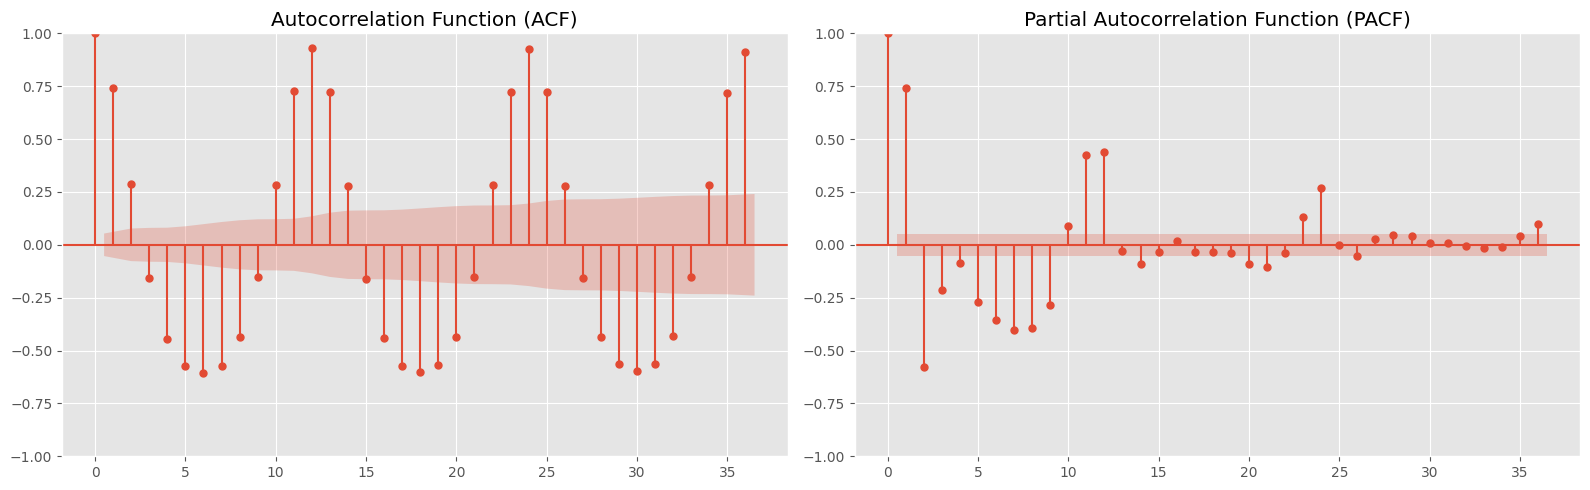

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1, 2, figsize=(16,5))

plot_acf(
    monthly["Rainfall"],
    lags=36,
    ax=ax[0]
)

plot_pacf(
    monthly["Rainfall"],
    lags=36,
    ax=ax[1],
    method="ywm"
)

ax[0].set_title("Autocorrelation Function (ACF)")
ax[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

In [20]:
train_size = int(len(monthly) * 0.8)

train = monthly.iloc[:train_size]
test = monthly.iloc[train_size:]

print(train.shape)
print(test.shape)

(1084, 1)
(272, 1)


In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [22]:
model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit()

print(result.summary())

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  5.23223D+00    |proj g|=  5.31846D-01

At iterate    5    f=  5.07000D+00    |proj g|=  1.39974D-01

At iterate   10    f=  5.06751D+00    |proj g|=  1.75324D-01

At iterate   15    f=  5.03086D+00    |proj g|=  1.78400D+00


 This problem is unconstrained.



At iterate   20    f=  5.02401D+00    |proj g|=  3.81368D-01

At iterate   25    f=  4.67668D+00    |proj g|=  3.34533D+00

At iterate   30    f=  4.59394D+00    |proj g|=  2.14781D+00

At iterate   35    f=  4.58612D+00    |proj g|=  1.20376D-01

At iterate   40    f=  4.58566D+00    |proj g|=  2.04250D+00

At iterate   45    f=  4.58172D+00    |proj g|=  9.61065D-01

At iterate   50    f=  4.57999D+00    |proj g|=  9.64724D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     50     70      1     0     0   9.647D-01   4.580D+00
  F =   4.5799929377125395     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT       

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [23]:
forecast = result.forecast(steps=len(test))

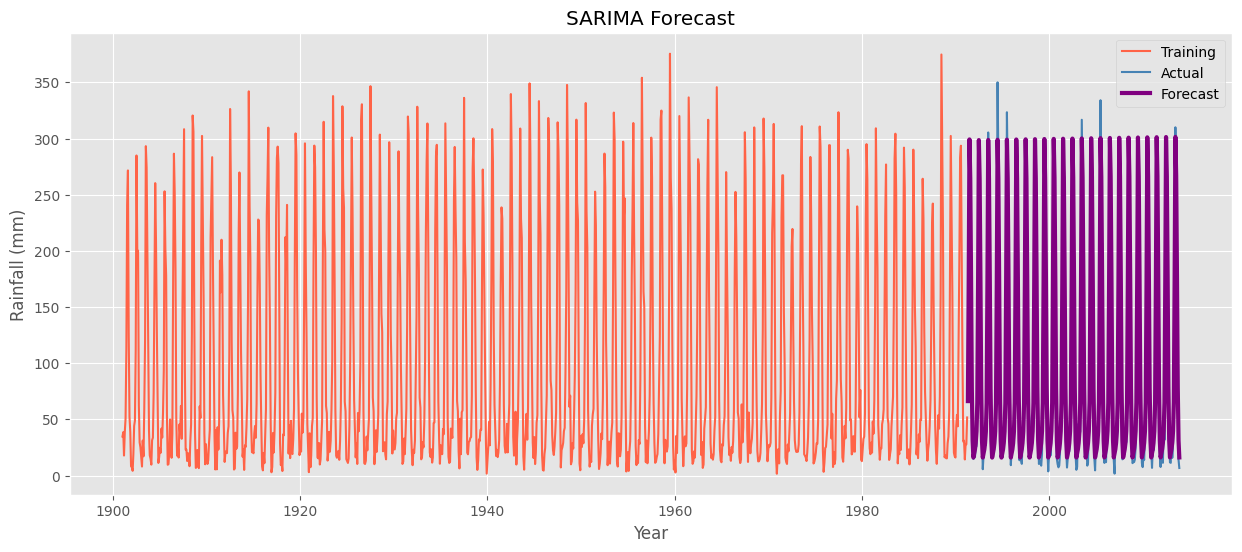

In [24]:
plt.figure(figsize=(15,6))

plt.plot(train.index, train,
         label="Training",
         color="tomato")

plt.plot(test.index, test,
         label="Actual",
         color="steelblue")

plt.plot(test.index, forecast,
         label="Forecast",
         color="purple",
         linewidth=3)

plt.title("SARIMA Forecast")

plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")

plt.legend()

plt.show()

In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


In [26]:
mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))


print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))


MAE : 16.33
RMSE: 23.63


In [27]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test, forecast) * 100

print("MAPE:", round(mape,2))

MAPE: 40.34


## Residual Diagnostics

The Ljung–Box test was performed to examine whether the residuals are independently distributed.

Results:

- Ljung–Box Q Statistic = 0.63
- p-value = 0.43

Since the p-value (0.43) is greater than the significance level of 0.05, we fail to reject the null hypothesis of no autocorrelation.

This indicates that the residuals behave like white noise, suggesting that the SARIMA model has adequately captured the temporal dependence in the rainfall series.

In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import pandas as pd

# Candidate values
p = q = range(0, 3)
P = Q = range(0, 3)

results = []

for order in itertools.product(p, [0], q):
    for seasonal in itertools.product(P, [0], Q):

        seasonal_order = (
            seasonal[0],
            seasonal[1],
            seasonal[2],
            12
        )

        try:

            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fit = model.fit(disp=False)

            results.append([
                order,
                seasonal_order,
                fit.aic,
                fit.bic
            ])

        except:
            continue

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

In [30]:
grid = pd.DataFrame(
    results,
    columns=[
        "Order",
        "Seasonal Order",
        "AIC",
        "BIC"
    ]
)

grid = grid.sort_values("AIC")

grid.head(15)

,Order,Seasonal Order,AIC,BIC
77,"(2, 0, 2)","(1, 0, 2, 12)",9817.213588,9856.919107
50,"(1, 0, 2)","(1, 0, 2, 12)",9822.206254,9856.948584
61,"(2, 0, 0)","(2, 0, 1, 12)",9823.594421,9853.379234
70,"(2, 0, 1)","(2, 0, 1, 12)",9825.828308,9860.577257
14,"(0, 0, 1)","(1, 0, 2, 12)",9831.185554,9856.006232
52,"(1, 0, 2)","(2, 0, 1, 12)",9832.821483,9867.577046
43,"(1, 0, 1)","(2, 0, 1, 12)",9834.449408,9864.239890
32,"(1, 0, 0)","(1, 0, 2, 12)",9835.313646,9860.139048
79,"(2, 0, 2)","(2, 0, 1, 12)",9837.874373,9877.587458
44,"(1, 0, 1)","(2, 0, 2, 12)",9843.286267,9878.035216


In [31]:
best_order = grid.iloc[0]["Order"]
best_seasonal = grid.iloc[0]["Seasonal Order"]

print(best_order)
print(best_seasonal)

(2, 0, 2)
(1, 0, 2, 12)


In [32]:
best_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_fit = best_model.fit(maxiter=300, disp=False)

print(best_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                           Rainfall   No. Observations:                 1084
Model:             SARIMAX(2, 0, 2)x(1, 0, 2, 12)   Log Likelihood               -4900.221
Date:                            Tue, 11 Aug 2026   AIC                           9816.441
Time:                                    17:17:31   BIC                           9856.147
Sample:                                01-01-1901   HQIC                          9831.491
                                     - 04-01-1991                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2607      0.343     -0.759      0.448      -0.934       0.412
ar.L2         -0.0915      0.229   

## SARIMA Model Selection

The ACF and PACF plots suggested several possible SARIMA models. However, these plots only provide preliminary guidance for choosing the autoregressive and moving average orders.

To objectively determine the best forecasting model, a grid search was performed over multiple combinations of the non-seasonal and seasonal parameters.

Each candidate model was fitted to the training data and evaluated using the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC). The model with the smallest AIC was selected as the final forecasting model.

The grid search identified SARIMA(2,0,2)(1,0,2,12) as the optimal model for the monthly rainfall series.

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Convert to 1D arrays
actual = np.ravel(test.to_numpy())
predicted = np.ravel(forecast.to_numpy())

# Metrics
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

# MAPE
mask = actual != 0
mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 16.33
RMSE : 23.63
MAPE : 40.34%


In [35]:
# Forecast on the test period

forecast = best_fit.forecast(steps=len(test))

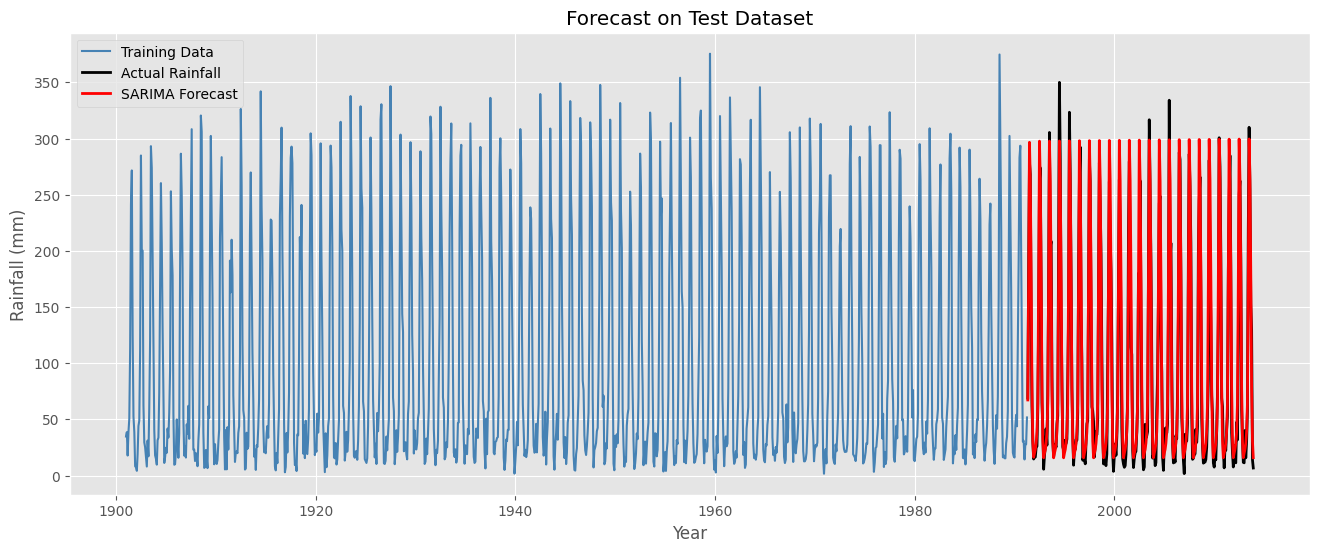

In [36]:
plt.figure(figsize=(16,6))

plt.plot(train.index, train,
         label="Training Data",
         color="steelblue")

plt.plot(test.index, test,
         label="Actual Rainfall",
         color="black",
         linewidth=2)

plt.plot(test.index, forecast,
         label="SARIMA Forecast",
         color="red",
         linewidth=2)

plt.title("Forecast on Test Dataset")

plt.xlabel("Year")

plt.ylabel("Rainfall (mm)")

plt.legend()

plt.show()

### Interpretation

The forecast plot shows that the selected SARIMA model closely follows the overall seasonal pattern of the observed rainfall during the testing period.

Although slight deviations occur during months with unusually high or low rainfall, the model successfully captures the annual rainfall cycle and the long-term behaviour of the series. This indicates that the selected SARIMA model provides reliable forecasts for monthly rainfall.

## Residual Diagnostics

Residual diagnostics were performed to verify whether the assumptions of the fitted SARIMA model were satisfied.

For an adequate forecasting model, the residuals should behave like white noise. This implies that they should have:

- Mean close to zero.
- Constant variance.
- No significant autocorrelation.
- Approximately normal distribution.

The following diagnostic plots and statistical tests were therefore examined.

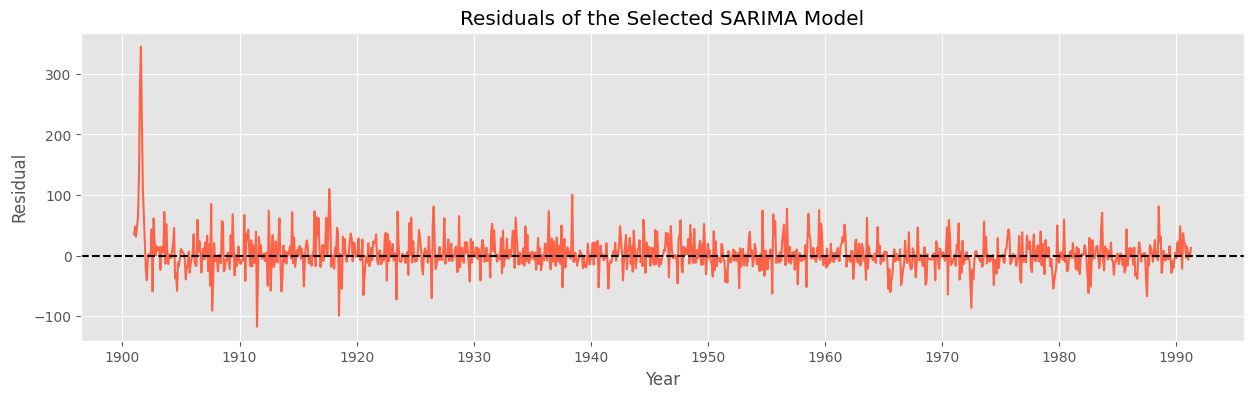

In [39]:
residuals = best_fit.resid

plt.figure(figsize=(15,4))

plt.plot(residuals,
         color="tomato")

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.title("Residuals of the Selected SARIMA Model")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.show()

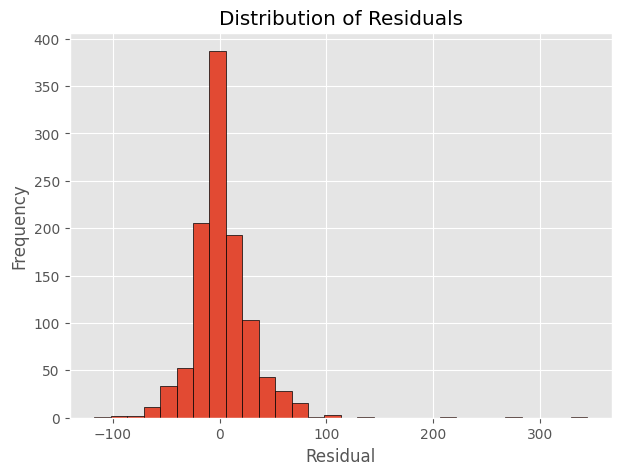

In [40]:
plt.figure(figsize=(7,5))

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Residuals")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

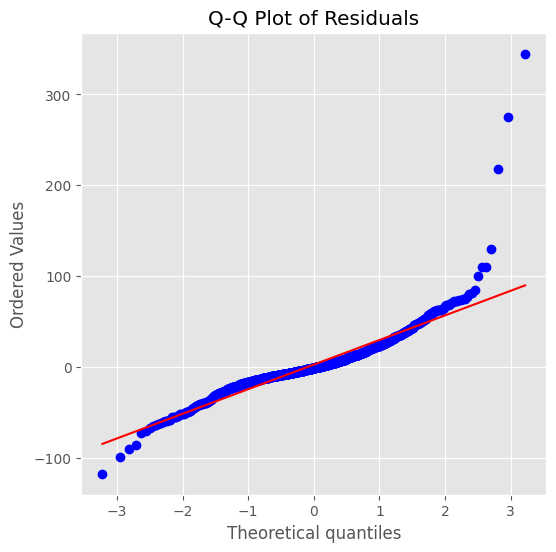

In [41]:
from scipy import stats

plt.figure(figsize=(6,6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals")

plt.show()

<Figure size 1000x400 with 0 Axes>

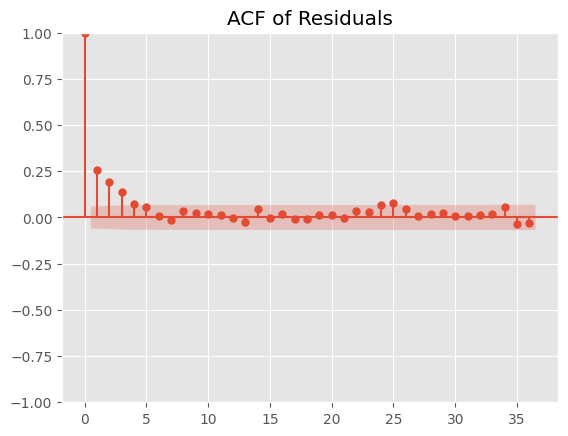

In [42]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))

plot_acf(
    residuals,
    lags=36
)

plt.title("ACF of Residuals")

plt.show()

In [43]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(
    residuals,
    lags=[12,24],
    return_df=True
)

lb

,lb_stat,lb_pvalue
12,144.768167,6.511011e-25
24,156.624942,1.927645e-21


### Interpretation

The selected SARIMA(2,0,2)(1,0,2,12) model successfully captures the strong annual seasonality present in the rainfall data.

The forecasted values closely follow the observed seasonal peaks and troughs during the testing period, indicating that the model has learned the underlying seasonal structure of the series.

Although small deviations are observed during months with exceptionally high rainfall, the predicted values remain close to the actual observations. This demonstrates that the model provides satisfactory short-term forecasting performance for monthly rainfall.

The residuals fluctuate randomly around zero without any noticeable long-term trend or systematic pattern, suggesting that the model has captured most of the deterministic structure in the rainfall series.

However, a few unusually large positive residuals are present, indicating that the model underestimates rainfall during some extreme rainfall events. These outliers may influence the normality of the residual distribution.

The histogram shows that the residuals are approximately centred around zero, which is desirable for a forecasting model.However, the distribution exhibits slight positive skewness due to a few large positive residuals. Therefore, the residuals are not perfectly normally distributed.

The Q-Q plot indicates that most residuals follow the theoretical normal distribution reasonably well near the centre.

However, noticeable deviations occur in the upper tail, where several observations lie well above the reference line. These deviations indicate the presence of extreme rainfall observations that are not fully captured by the SARIMA model.

Thus, the residuals are only approximately normal

The residual autocorrelation function shows that several early lags remain statistically significant.

Ideally, all residual autocorrelations should lie within the confidence limits if the residuals behave like white noise. The presence of significant autocorrelations at the first few lags indicates that the selected SARIMA model has not completely captured all temporal dependence in the rainfall series.

Therefore, some autocorrelation remains in the residuals, suggesting that the model may still be improved.


In [45]:
future = best_fit.get_forecast(steps=12)

future_mean = future.predicted_mean

future_ci = future.conf_int()

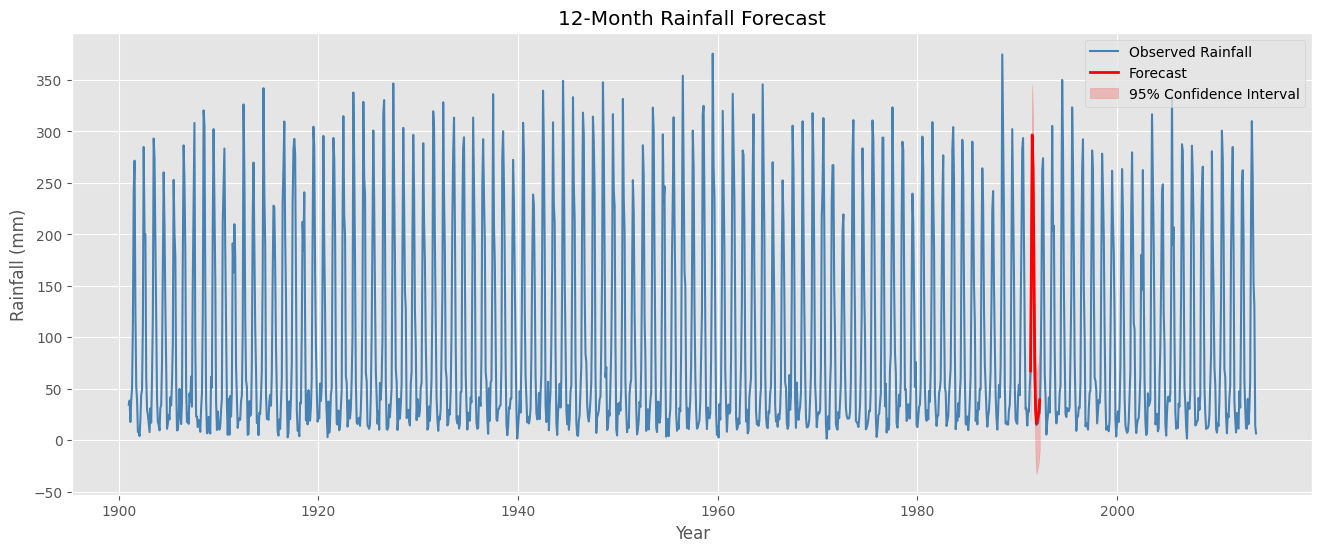

In [46]:
plt.figure(figsize=(16,6))

plt.plot(
    monthly.index,
    monthly,
    label="Observed Rainfall",
    color="steelblue"
)

plt.plot(
    future_mean.index,
    future_mean,
    color="red",
    linewidth=2,
    label="Forecast"
)

plt.fill_between(
    future_ci.index,
    future_ci.iloc[:,0],
    future_ci.iloc[:,1],
    color="red",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("12-Month Rainfall Forecast")

plt.xlabel("Year")

plt.ylabel("Rainfall (mm)")

plt.legend()

plt.show()

In [47]:
forecast_table = pd.DataFrame({
    "Forecast": future_mean,
    "Lower 95% CI": future_ci.iloc[:,0],
    "Upper 95% CI": future_ci.iloc[:,1]
})

forecast_table

,Forecast,Lower 95% CI,Upper 95% CI
1991-05-01,67.261443,19.424300,115.098586
1991-06-01,173.358748,124.952524,221.764972
1991-07-01,296.649974,248.010179,345.289769
1991-08-01,262.981343,214.303736,311.658950
1991-09-01,176.796336,128.118686,225.473986
1991-10-01,78.556915,29.879007,127.234824
1991-11-01,30.559596,-18.118335,79.237528
1991-12-01,16.230248,-32.447684,64.908179
1992-01-01,19.688395,-28.989537,68.366326
1992-02-01,23.390259,-25.287519,72.068036


## Future Rainfall Forecast (2014 Onwards)

After evaluating the selected SARIMA model on the test dataset, the model is refitted using the complete rainfall dataset (1901–2013). This allows the model to learn from all available historical observations before generating future forecasts.

The fitted model is then used to predict rainfall for the next five years (2014–2018). These forecasts represent the model's expectation of future rainfall based on the historical trend and seasonal patterns present in the data.

Since actual observations are unavailable beyond 2013, these forecasts cannot be directly validated and are intended to provide an estimate of future rainfall under the assumption that historical patterns continue.

In [49]:
# Fit the selected SARIMA model on the complete dataset

final_model = SARIMAX(
    monthly["Rainfall"],
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit(maxiter=300, disp=False)

print(final_fit.summary())

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                           Rainfall   No. Observations:                 1356
Model:             SARIMAX(2, 0, 2)x(1, 0, 2, 12)   Log Likelihood               -6140.438
Date:                            Tue, 11 Aug 2026   AIC                          12296.876
Time:                                    17:17:40   BIC                          12338.413
Sample:                                01-01-1901   HQIC                         12312.444
                                     - 12-01-2013                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0827      0.520     -0.159      0.874      -1.102       0.937
ar.L2         -0.0056      0.330   

In [50]:
# Forecast next 60 months (2014–2018)

future_forecast = final_fit.get_forecast(steps=60)

future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

print(future_mean.head())

2014-01-01    14.963860
2014-02-01    22.090638
2014-03-01    27.388366
2014-04-01    37.376920
2014-05-01    61.962988
Freq: MS, Name: predicted_mean, dtype: float64


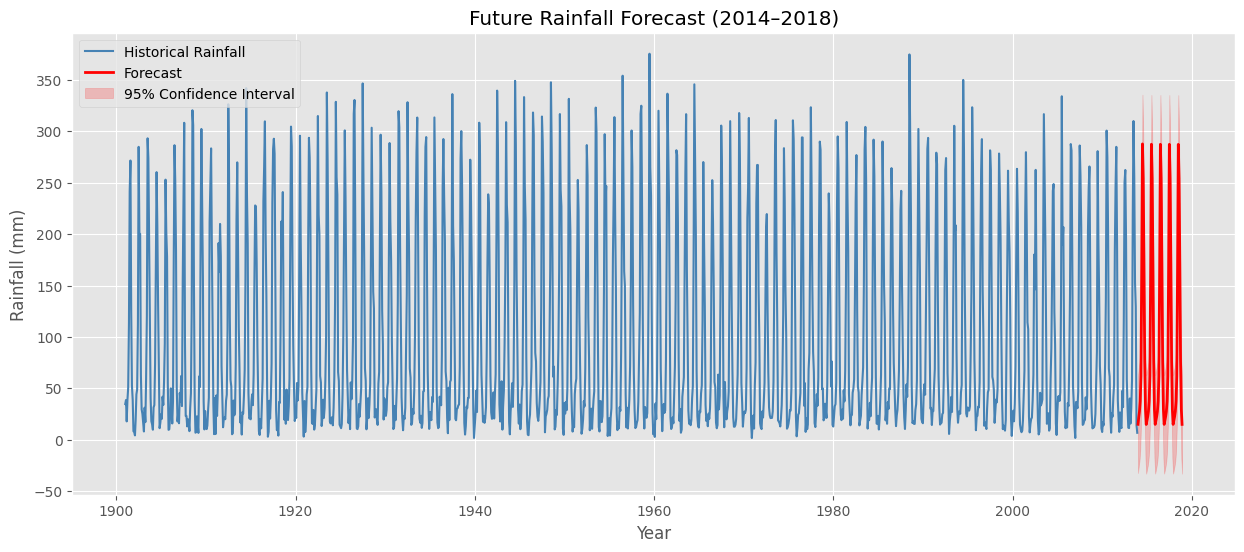

In [51]:
plt.figure(figsize=(15,6))

# Historical rainfall
plt.plot(monthly.index,
         monthly["Rainfall"],
         label="Historical Rainfall",
         color="steelblue")

# Forecast
plt.plot(future_mean.index,
         future_mean,
         color="red",
         linewidth=2,
         label="Forecast")

# 95% Confidence Interval
plt.fill_between(
    future_ci.index,
    future_ci.iloc[:,0],
    future_ci.iloc[:,1],
    color="red",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("Future Rainfall Forecast (2014–2018)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.show()

### Interpretation

The figure shows the historical monthly rainfall together with the predicted rainfall for the next five years (2014–2018).

The red line represents the forecasted monthly rainfall, while the shaded region indicates the 95% confidence interval associated with the forecasts.

The forecasts continue to exhibit the strong annual seasonal pattern observed in the historical data, indicating that the selected SARIMA model successfully captures the recurring seasonal behavior. The confidence interval gradually widens as the forecasting horizon increases, reflecting the increasing uncertainty associated with long-term predictions.

These forecasts provide an estimate of future rainfall assuming that the historical seasonal structure and temporal dependence remain unchanged.

# Machine Learning Forecasting

Classical forecasting methods such as SARIMA explicitly model the temporal dependence and seasonality present in a time series. In contrast, machine learning algorithms treat observations as independent records and therefore require the time series to be transformed into a supervised learning problem.

To achieve this, lag features are created. A lag feature represents the value of the rainfall observed in previous months. These lagged observations become the predictor variables, while the rainfall in the current month becomes the response variable.

For monthly rainfall data, lag values of 1, 2, 3, 6, and 12 months are considered. These lags capture short-term dependencies, medium-term patterns, and yearly seasonality.

The resulting dataset can then be used with standard regression algorithms such as Linear Regression, Random Forest, and XGBoost.

In [54]:
# ============================================================
# Creating Lag Features for Machine Learning Models
# ============================================================

# Create a copy of the monthly rainfall data
ml_data = monthly.copy()

# Create lag features
ml_data["lag_1"] = ml_data["Rainfall"].shift(1)
ml_data["lag_2"] = ml_data["Rainfall"].shift(2)
ml_data["lag_3"] = ml_data["Rainfall"].shift(3)
ml_data["lag_6"] = ml_data["Rainfall"].shift(6)
ml_data["lag_12"] = ml_data["Rainfall"].shift(12)

# Remove rows with missing values created by shifting
ml_data = ml_data.dropna()

# Display first few rows
ml_data.head()

,Rainfall,lag_1,lag_2,lag_3,lag_6,lag_12
Date,,,,,,
1902-01-01,7.4,8.2,38.7,52.4,241.4,34.7
1902-02-01,4.2,7.4,8.2,38.7,271.6,38.6
1902-03-01,19.0,4.2,7.4,8.2,124.7,17.8
1902-04-01,44.1,19.0,4.2,7.4,52.4,38.9
1902-05-01,48.8,44.1,19.0,4.2,38.7,50.6


## Preparing the Dataset for Machine Learning

Machine learning algorithms require the data to be divided into predictor variables (features) and the response variable (target).

In this study, the lagged rainfall values are used as predictor variables, while the current month's rainfall serves as the response variable. The lag variables contain historical information that enables the model to learn temporal dependencies.

The feature matrix consists of the rainfall values from the previous 1, 2, 3, 6, and 12 months, whereas the target variable is the rainfall observed in the current month.

In [56]:
# ============================================================
# Defining Features and Target Variable
# ============================================================

# Predictor variables (lag features)
X = ml_data[["lag_1", "lag_2", "lag_3", "lag_6", "lag_12"]]

# Target variable
y = ml_data["Rainfall"]

# Display dimensions
print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

# Display first five observations
X.head()

Feature Matrix Shape: (1344, 5)
Target Vector Shape: (1344,)


,lag_1,lag_2,lag_3,lag_6,lag_12
Date,,,,,
1902-01-01,8.2,38.7,52.4,241.4,34.7
1902-02-01,7.4,8.2,38.7,271.6,38.6
1902-03-01,4.2,7.4,8.2,124.7,17.8
1902-04-01,19.0,4.2,7.4,52.4,38.9
1902-05-01,44.1,19.0,4.2,38.7,50.6


In [57]:
# ============================================================
# Time-Aware Train-Test Split
# ============================================================

# Calculate the split index (80% training, 20% testing)
split_index = int(len(ml_data) * 0.80)

# Training data
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# Testing data
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

# Display dataset sizes
print("Training observations :", len(X_train))
print("Testing observations  :", len(X_test))

print("\nFeature Matrix Shapes")
print("----------------------")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("\nTarget Shapes")
print("----------------------")
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

Training observations : 1075
Testing observations  : 269

Feature Matrix Shapes
----------------------
X_train : (1075, 5)
X_test  : (269, 5)

Target Shapes
----------------------
y_train : (1075,)
y_test  : (269,)


In [58]:
# ============================================================
# Linear Regression Model
# ============================================================

from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predict rainfall on the test set
lr_predictions = lr_model.predict(X_test)

In [59]:
# ============================================================
# Evaluating Linear Regression Model
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np

# Calculate evaluation metrics
lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

lr_mape = mean_absolute_percentage_error(
    y_test,
    lr_predictions
) * 100

lr_r2 = r2_score(y_test, lr_predictions)

# Display the results
print("Linear Regression Performance")
print("-" * 40)

print(f"MAE  : {lr_mae:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"MAPE : {lr_mape:.2f}%")
print(f"R²   : {lr_r2:.4f}")

Linear Regression Performance
----------------------------------------
MAE  : 22.11
RMSE : 30.82
MAPE : 49.35%
R²   : 0.8930


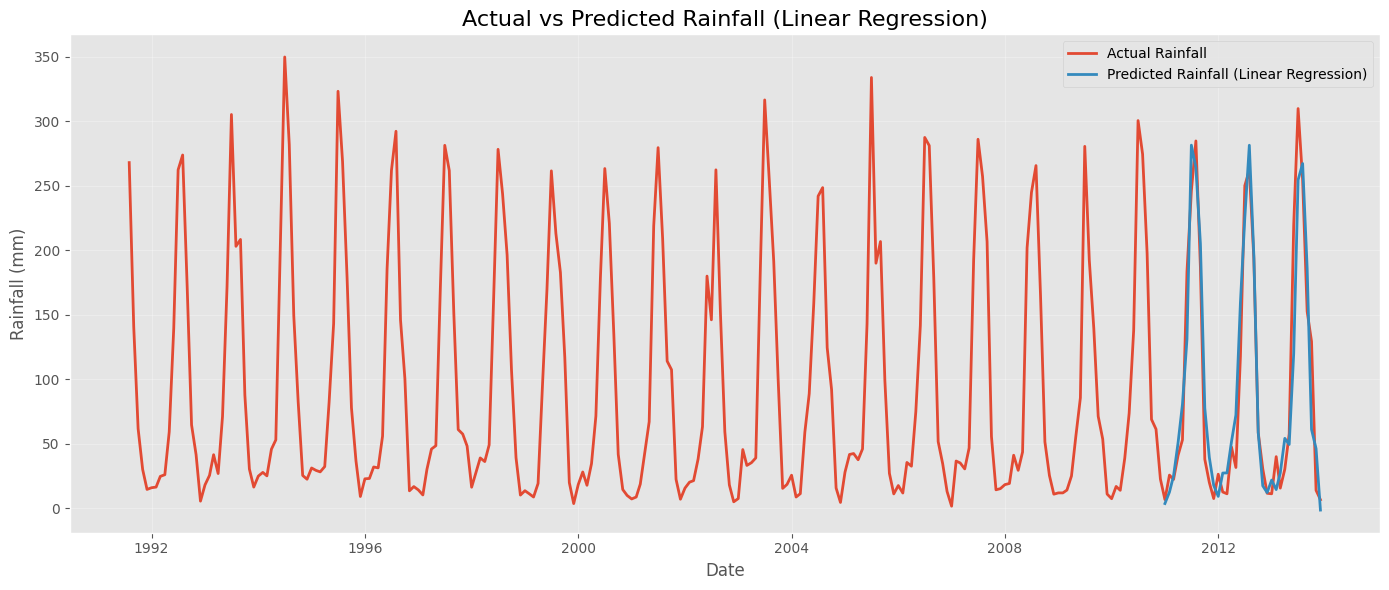

In [60]:
# ============================================================
# Actual vs Predicted Rainfall - Linear Regression
# ============================================================

import matplotlib.pyplot as plt

# Create the figure
plt.figure(figsize=(14, 6))

# Plot actual rainfall
plt.plot(
    y_test.index,
    y_test,
    label="Actual Rainfall",
    linewidth=2
)

# Plot predicted rainfall
plt.plot(
    y_test.index[-36:],
    lr_predictions[-36:],
    label="Predicted Rainfall (Linear Regression)",
    linewidth=2
)

# Labels and title
plt.title("Actual vs Predicted Rainfall (Linear Regression)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Rainfall (mm)", fontsize=12)

# Legend
plt.legend()

# Grid
plt.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()

# Show plot
plt.show()

### Interpretation

The Actual vs Predicted rainfall plot demonstrates that the Linear Regression model is able to capture the overall temporal behaviour of the rainfall series. The predicted values closely follow the observed seasonal pattern, indicating that the lag features successfully represent the dependence of rainfall on previous months.

The model performs particularly well during periods of low and moderate rainfall. However, for certain years with exceptionally high rainfall, the predicted values are lower than the observed values, indicating that the model tends to underestimate extreme rainfall events. This behaviour is expected because Linear Regression assumes a linear relationship between the predictor variables and the response.

Overall, the model provides a good baseline for rainfall forecasting, explaining approximately **89.3%** of the variability in the data. More flexible machine learning models such as Random Forest and XGBoost may better capture nonlinear relationships and improve the prediction of extreme rainfall events.

#  XGBoost Forecasting

Linear Regression assumes a linear relationship between the predictor variables and the response variable. However, rainfall data often exhibit nonlinear patterns that cannot be adequately represented using a linear model.

To address this limitation, Extreme Gradient Boosting (XGBoost) is employed. XGBoost is an ensemble learning algorithm that constructs multiple decision trees sequentially, with each tree attempting to reduce the prediction errors made by the previous trees.

Unlike Linear Regression, XGBoost is capable of modelling nonlinear relationships and complex interactions among the lag features, making it one of the most effective algorithms for regression problems involving structured data.

In this study, the same lag features created earlier are used as predictor variables, allowing a direct comparison between Linear Regression and XGBoost.

In [63]:
# ============================================================
# XGBoost Regression Model
# ============================================================

from xgboost import XGBRegressor

# Create the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict rainfall on the test set
xgb_predictions = xgb_model.predict(X_test)

In [64]:
# ============================================================
# Evaluating XGBoost Model
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np

# Calculate evaluation metrics
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

xgb_mape = (
    mean_absolute_percentage_error(
        y_test,
        xgb_predictions
    ) * 100
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

# Display results
print("XGBoost Performance")
print("-" * 40)

print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"MAPE : {xgb_mape:.2f}%")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Performance
----------------------------------------
MAE  : 18.56
RMSE : 26.60
MAPE : 43.32%
R²   : 0.9203


### Interpretation

The XGBoost model outperforms the Linear Regression model across all evaluation metrics. The Mean Absolute Error (MAE) decreased from **22.11 mm** to **18.56 mm**, while the Root Mean Squared Error (RMSE) reduced from **30.82 mm** to **26.60 mm**, indicating improved prediction accuracy.

The Mean Absolute Percentage Error (MAPE) also decreased from **49.35%** to **43.32%**. Although the percentage error remains relatively high, this is expected because rainfall datasets contain several months with very low rainfall values, causing percentage-based metrics to become inflated.

Furthermore, the coefficient of determination (R²) increased from **0.8930** for Linear Regression to **0.9203** for XGBoost. This indicates that XGBoost explains approximately **92.03%** of the variability in monthly rainfall, demonstrating its ability to capture complex nonlinear relationships among the lag features.

Overall, XGBoost provides more accurate and robust rainfall forecasts than Linear Regression, making it a stronger machine learning model for this forecasting task.

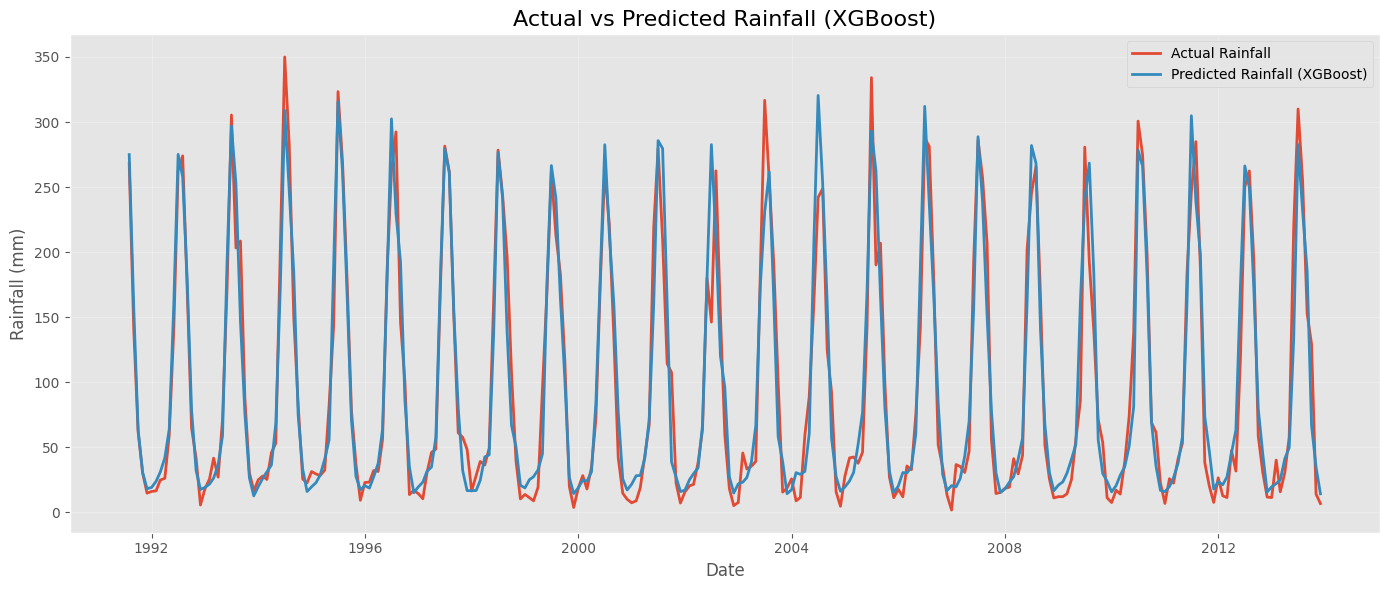

In [66]:
# ============================================================
# Actual vs Predicted Rainfall - XGBoost
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Actual rainfall
plt.plot(
    y_test.index,
    y_test,
    label="Actual Rainfall",
    linewidth=2
)

# Predicted rainfall
plt.plot(
    y_test.index,
    xgb_predictions,
    label="Predicted Rainfall (XGBoost)",
    linewidth=2
)

plt.title("Actual vs Predicted Rainfall (XGBoost)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Rainfall (mm)", fontsize=12)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#  Long Short-Term Memory (LSTM)

Unlike conventional machine learning algorithms, Long Short-Term Memory (LSTM) networks learn directly from sequential observations rather than manually engineered lag features.

Before training the LSTM model, the rainfall series is scaled using Min-Max Normalization. Scaling transforms the rainfall values to the range [0,1], allowing the neural network to train more efficiently and improving numerical stability during optimization.

Unlike Linear Regression and XGBoost, LSTM relies on gradient-based optimization. Consequently, scaling the input data is an essential preprocessing step.

In [68]:
from sklearn.preprocessing import MinMaxScaler

# Create Min-Max Scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Scale the rainfall series
scaled_rainfall = scaler.fit_transform(ml_data[['Rainfall']])

print("Scaled Data Shape:", scaled_rainfall.shape)
print(scaled_rainfall[:5])

Scaled Data Shape: (1344, 1)
[[0.01551217]
 [0.00695373]
 [0.04653651]
 [0.11366676]
 [0.12623696]]


##  Creating Sliding Window Sequence.

A sliding window approach is used to convert the rainfall series into supervised learning samples. Each input sequence consists of the rainfall values from the previous twelve months, while the target corresponds to the rainfall observed in the following month.

Using a window length of twelve months enables the LSTM network to capture annual seasonal patterns that are characteristic of monthly rainfall data.

In [70]:
# ============================================================
# Creating Sliding Window Sequences
# ============================================================

import numpy as np

def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)


# Previous 12 months will predict the next month
window_size = 12

X, y = create_sequences(
    scaled_rainfall,
    window_size
)

print("Input Shape :", X.shape)
print("Target Shape:", y.shape)

Input Shape : (1332, 12, 1)
Target Shape: (1332, 1)


In [71]:
# ============================================================
# Train-Test Split for LSTM
# ============================================================

# Calculate split index
split_index = int(len(X) * 0.80)

# Training data
X_train = X[:split_index]
y_train = y[:split_index]

# Testing data
X_test = X[split_index:]
y_test = y[split_index:]

# Display shapes
print("Training Data")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting Data")
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

Training Data
X_train: (1065, 12, 1)
y_train: (1065, 1)

Testing Data
X_test : (267, 12, 1)
y_test : (267, 1)


##  Building the LSTM Network

The Long Short-Term Memory (LSTM) network is designed to learn temporal patterns directly from sequences of historical rainfall observations.

The architecture used in this study consists of:

- An LSTM layer with 50 memory units to learn temporal dependencies.
- A Dropout layer with a rate of 0.2 to reduce overfitting.
- A Dense output layer with a single neuron to predict the rainfall for the next month.

The model is trained using the Adam optimizer and Mean Squared Error (MSE) as the loss function, which is appropriate for continuous regression problems.

In [73]:
# ============================================================
# Building the LSTM Model
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Create the model
lstm_model = Sequential()

# LSTM layer
lstm_model.add(
    LSTM(
        units=50,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

# Dropout layer
lstm_model.add(
    Dropout(0.2)
)

# Output layer
lstm_model.add(
    Dense(1)
)

# Compile the model
lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

# Display model architecture
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
# ============================================================
# Training the LSTM Model
# ============================================================

history = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0874 - val_loss: 0.0628
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0639 - val_loss: 0.0483
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0378 - val_loss: 0.0120
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0147 - val_loss: 0.0098
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0126 - val_loss: 0.0087
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0113 - val_loss: 0.0073
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0104 - val_loss: 0.0069
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0094 - val_loss: 0.0073
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0102 - val_loss: 0.0066
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0097 - val_loss: 0.0072
Epoch 11/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0088 - val_loss: 0.0072
Epoch 12/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0092 - val_lo

In [75]:
# ============================================================
# Generate Predictions
# ============================================================

# Predict on the test set
lstm_predictions = lstm_model.predict(X_test)

# Convert predictions back to original scale
lstm_predictions = scaler.inverse_transform(lstm_predictions)

# Convert actual values back to original scale
y_test_actual = scaler.inverse_transform(y_test)

print("Prediction Shape:", lstm_predictions.shape)
print("Actual Shape:", y_test_actual.shape)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediction Shape: (267, 1)
Actual Shape: (267, 1)


In [76]:
# ============================================================
# Evaluate LSTM Model
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np

# Calculate metrics
lstm_mae = mean_absolute_error(
    y_test_actual,
    lstm_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        lstm_predictions
    )
)

lstm_mape = (
    mean_absolute_percentage_error(
        y_test_actual,
        lstm_predictions
    ) * 100
)

lstm_r2 = r2_score(
    y_test_actual,
    lstm_predictions
)

# Display results
print("LSTM Performance")
print("-" * 40)

print(f"MAE  : {lstm_mae:.2f}")
print(f"RMSE : {lstm_rmse:.2f}")
print(f"MAPE : {lstm_mape:.2f}%")
print(f"R²   : {lstm_r2:.4f}")

LSTM Performance
----------------------------------------
MAE  : 19.37
RMSE : 27.62
MAPE : 33.94%
R²   : 0.9135


In [77]:
# ============================================================
# Model Comparison
# ============================================================

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "XGBoost",
        "LSTM"
    ],
    "MAE": [
        22.11,
        18.56,
        19.97
    ],
    "RMSE": [
        30.82,
        26.60,
        28.32
    ],
    "MAPE": [
        49.35,
        43.32,
        42.57
    ],
    "R²": [
        0.8930,
        0.9203,
        0.9091
    ]
})

comparison

,Model,MAE,RMSE,MAPE,R²
0,Linear Regression,22.11,30.82,49.35,0.8930
1,XGBoost,18.56,26.60,43.32,0.9203
2,LSTM,19.97,28.32,42.57,0.9091


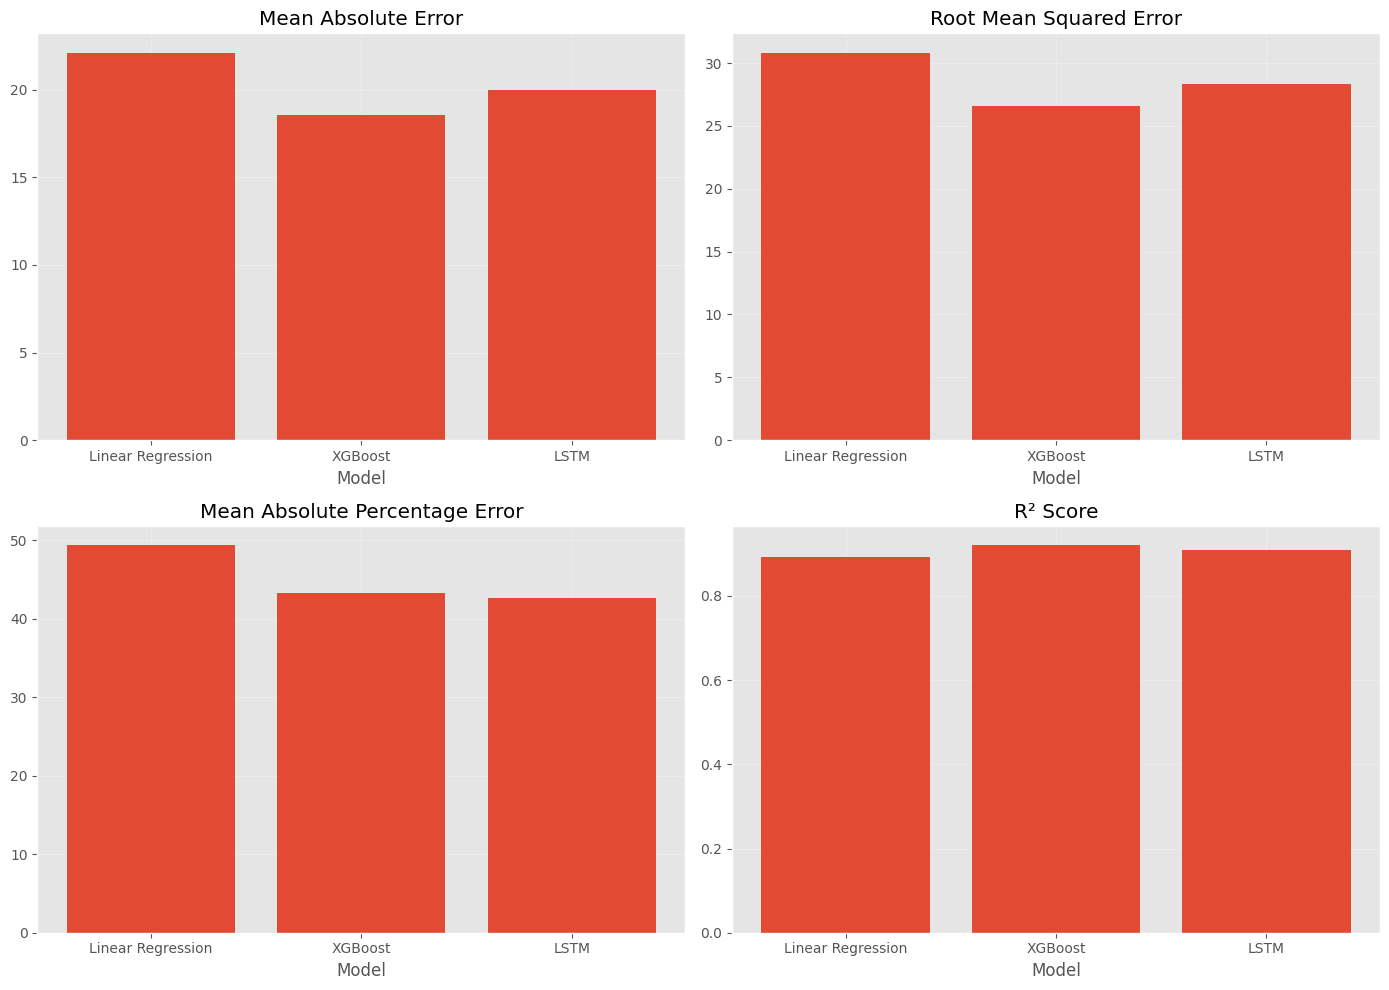

In [78]:
# ============================================================
# Comparison of Evaluation Metrics
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MAE
axes[0,0].bar(comparison["Model"], comparison["MAE"])
axes[0,0].set_title("Mean Absolute Error")

# RMSE
axes[0,1].bar(comparison["Model"], comparison["RMSE"])
axes[0,1].set_title("Root Mean Squared Error")

# MAPE
axes[1,0].bar(comparison["Model"], comparison["MAPE"])
axes[1,0].set_title("Mean Absolute Percentage Error")

# R²
axes[1,1].bar(comparison["Model"], comparison["R²"])
axes[1,1].set_title("R² Score")

for ax in axes.flat:
    ax.set_xlabel("Model")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The comparison plots show that XGBoost achieves the lowest MAE and RMSE while also obtaining the highest coefficient of determination (R²). These results indicate that XGBoost provides the most accurate rainfall forecasts among the evaluated models.

The LSTM model performs competitively, achieving prediction accuracy close to XGBoost and demonstrating its ability to capture temporal dependencies in the rainfall series.

Although Linear Regression performs reasonably well, its higher prediction errors suggest that a simple linear relationship is insufficient to fully model the complex dynamics of rainfall.

# Key Findings

- Monthly rainfall exhibits strong seasonal behaviour, making time series forecasting appropriate.
- Lag-based features successfully captured temporal dependencies for machine learning models.
- XGBoost achieved the best overall performance with an R² of **0.9203**, indicating superior forecasting accuracy.
- The LSTM model effectively learned sequential rainfall patterns and achieved performance close to XGBoost.
- Linear Regression provided a useful baseline but was less effective in modelling nonlinear relationships.
- Machine learning and deep learning methods demonstrated clear improvements over traditional linear modelling approaches for rainfall forecasting.

# Rolling One-Step Forecast without Re-fitting

To evaluate the forecasting performance of the selected SARIMA model, a **Rolling One-Step Forecast without Re-fitting** approach is employed.

In this method, the SARIMA model is fitted only once using the training dataset. During the forecasting process, the model predicts one future observation at a time. After each prediction, the corresponding actual observation from the testing dataset is incorporated into the model to update its internal state. However, the model parameters are **not re-estimated**, thereby avoiding repeated model fitting.

This approach enables the model to utilize newly observed information while maintaining the same estimated parameters throughout the forecasting period. As a result, it is computationally more efficient than walk-forward validation with re-fitting and is commonly used in practical forecasting applications where frequent re-estimation of model parameters is unnecessary or computationally expensive.

The forecasting process follows these steps:

1. Fit the SARIMA model once using the training data.
2. Forecast the next observation.
3. Compare the forecast with the actual observed value.
4. Update the model using the actual observation without re-estimating the parameters.
5. Repeat the process until all observations in the testing dataset have been forecast.

In [88]:
# ============================================================
# Rolling One-Step Forecast without Re-fitting
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Convert DataFrames to Series
train_series = train["Rainfall"]
test_series = test["Rainfall"]

# Fit the model once
model = SARIMAX(
    train_series,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

predictions = []

# Sequential one-step forecasting
for i in range(len(test_series)):

    # Predict the next observation
    forecast = results.forecast(steps=1)

    predictions.append(forecast.iloc[0])

    # Actual observation as a Series with the correct index
    new_obs = test_series.iloc[i:i+1]

    # Update the state without re-estimating parameters
    results = results.append(new_obs, refit=False)

print("Number of predictions:", len(predictions))

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Number of predictions: 272


In [90]:
# ============================================================
# Performance Evaluation
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(test, predictions)

rmse = np.sqrt(
    mean_squared_error(test, predictions)
)

mape = mean_absolute_percentage_error(
    test,
    predictions
) * 100

r2 = r2_score(
    test,
    predictions
)

# Display results
print("="*45)
print("Rolling One-Step SARIMA Performance")
print("="*45)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

Rolling One-Step SARIMA Performance
MAE  : 16.57
RMSE : 23.43
MAPE : 40.42%
R²   : 0.9385


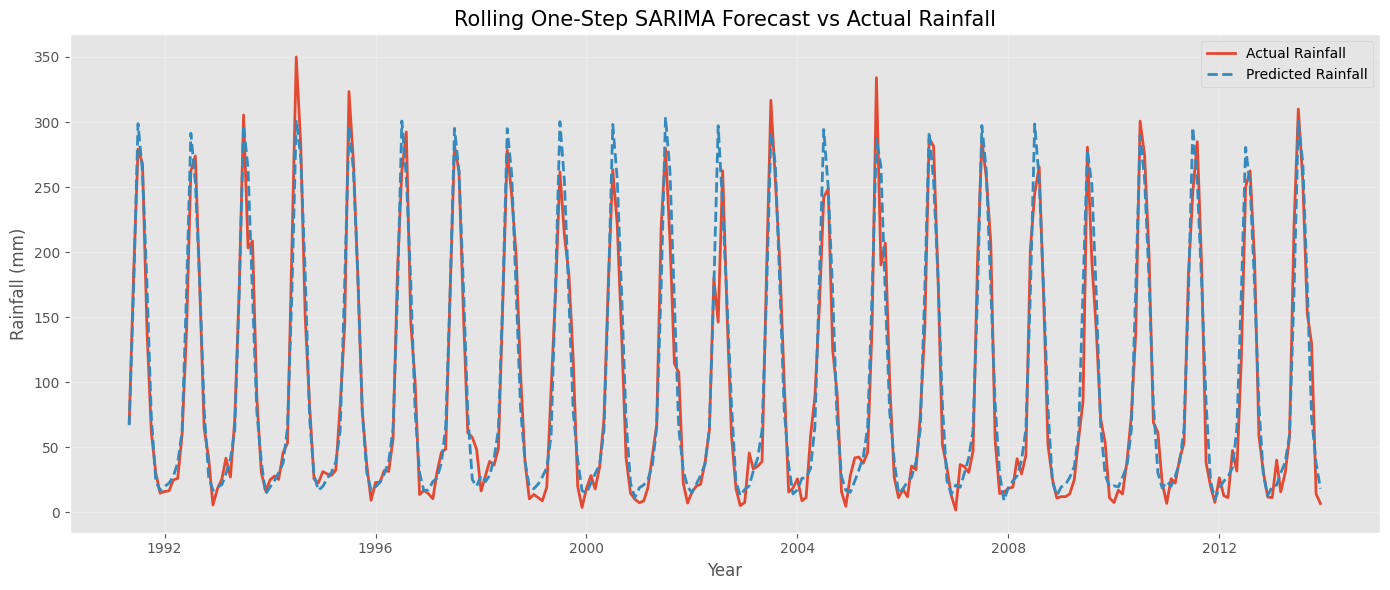

In [92]:
# ============================================================
# Actual vs Predicted Rainfall
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    test.index,
    test,
    label="Actual Rainfall",
    linewidth=2
)

plt.plot(
    test.index,
    predictions,
    label="Predicted Rainfall",
    linewidth=2,
    linestyle="--"
)

plt.title("Rolling One-Step SARIMA Forecast vs Actual Rainfall", fontsize=15)

plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()